# Monolayer Benchmark (High Performance)
This notebook runs the OpenVT monolayer benchmark on a large 2000x2000 grid for 20,000 steps.
It uses `KernelAbstractions.jl` allowing it to run completely on the GPU. You can select your hardware backend in the first cell.

In [1]:
# ==========================================
# 0. Ephemeral GPU Library Setup
# ==========================================
# This cell activates the local notebook environment, but installs 
# the GPU library into a TEMPORARY environment that will disappear 
# when you close the notebook. This keeps your local Project.toml clean!

using Pkg
Pkg.activate(@__DIR__)     # 1. Activate the local notebook folder
Pkg.instantiate()          # 2. Ensure core dependencies are installed

temp_env = mktempdir()     # 3. Create a temporary environment
Pkg.activate(temp_env)

# Uncomment the GPU library you want to install for this session:
Pkg.add("Metal")           # --- Apple Silicon (Mac) ---
# Pkg.add("CUDA")          # --- NVIDIA GPUs ---
# Pkg.add("AMDGPU")        # --- AMD GPUs ---

push!(LOAD_PATH, temp_env) # 4. Add temporary env to Julia's search path
Pkg.activate(@__DIR__)     # 5. Switch back to the local notebook folder
println("\nGPU Library installed ephemerally! Environment is clean.")

  Activating project at `~/Documents/Jiang/CPM 1.6/Potts.jl/examples/notebooks`
  Activating new project at `/var/folders/9d/d4gpx11s7vlbsnsd5y3n2z8r0000gn/T/jl_pXkada`
   Resolving package versions...
    Updating `/private/var/folders/9d/d4gpx11s7vlbsnsd5y3n2z8r0000gn/T/jl_pXkada/Project.toml`
  [dde4c033] + Metal v1.10.0
    Updating `/private/var/folders/9d/d4gpx11s7vlbsnsd5y3n2z8r0000gn/T/jl_pXkada/Manifest.toml`
  [621f4979] + AbstractFFTs v1.5.0
  [79e6a3ab] + Adapt v4.7.0
  [a9b6321e] + Atomix v1.1.3
  [ab4f0b2a] + BFloat16s v0.6.1
  [fa961155] + CEnum v0.5.0
  [523fee87] + CodecBzip2 v0.8.5
  [a8cc5b0e] + Crayons v4.1.1
  [9a962f9c] + DataAPI v1.16.0
  [e2d170a0] + DataValueInterfaces v1.0.0
  [e2ba6199] + ExprTools v0.1.10
  [0c68f7d7] + GPUArrays v11.5.8
  [46192b85] + GPUArraysCore v0.2.0
  [61eb1bfa] + GPUCompiler v1.22.7
  [096a3bc2] + GPUToolbox v3.0.0
  [076d061b] + HashArrayMappedTries v0.2.0
  [82899510] + IteratorInterfaceExtensions v1.0.0
  [692b3bcd] + JLLWrappers 


GPU Library installed ephemerally! Environment is clean.


project at `~/Documents/Jiang/CPM 1.6/Potts.jl/examples/notebooks`


In [2]:
# ==========================================
# Hardware Backend Selection
# ==========================================
# Uncomment the block corresponding to the library you installed above.

# --- Apple Silicon (Mac) ---
using Metal
backend = MetalBackend()
ArrayType = MtlArray

# --- NVIDIA GPUs ---
# using CUDA
# backend = CUDABackend()
# ArrayType = CuArray

# --- AMD GPUs ---
# using AMDGPU
# backend = ROCBackend()
# ArrayType = ROCArray

# --- CPU (Fallback, very slow for 2000x2000) ---
# backend = CPU()
# ArrayType = Array

MtlArray

In [3]:
using SciMLBase
using CommonSolve
using LinearAlgebra
using Random
using StructArrays
using CorePotts
using CorePotts.KernelAbstractions
using CorePotts.Atomix
using PottsToolkit

In [4]:
# ==========================================
# 1. Custom Monolayer Component & Penalty
# ==========================================

struct MonolayerPenalty <: CorePotts.AbstractPenalty{CorePotts.Rigid} end
CorePotts.evaluate_penalty(::MonolayerPenalty, ctx) = 0.0f0

struct MonolayerGrowthComponent <: AbstractComponent
    initial_area::Float32
    initial_div_thresh::Int32
end

import PottsToolkit.Problem: compile_component
import PottsToolkit.System: required_variables

required_variables(::MonolayerGrowthComponent) = (
    free_surfaces = Int32,
    inhibition_states = UInt8,
    target_volumes_float = Float32,
    division_threshold_volumes = Int32
)

function compile_component(comp::MonolayerGrowthComponent, type_to_id::Dict{CellType, UInt8}, num_types::Int64)
    trackers = [CorePotts.SurfaceAreaTracker()]
    
    props = Dict{UInt8, Dict{Symbol, Any}}()
    for (ct, id) in type_to_id
        if ct.name == :Tissue
            props[id] = Dict(
                :target_volumes_float => comp.initial_area,
                :target_volumes => floor(Int32, comp.initial_area),
                :target_surface_areas => floor(Int32, 4.0f0 * sqrt(comp.initial_area)),
                :division_threshold_volumes => comp.initial_div_thresh
            )
        end
    end
    
    return (MonolayerPenalty(), trackers, props)
end

compile_component (generic function with 7 methods)

In [5]:
# ==========================================
# 2. Custom Callbacks for Growth
# ==========================================

@kernel function _kernel_compute_free_surfaces!(free_surfaces, grid, topo, dims)
    i = @index(Global, Linear)
    cell_id = grid[i]
    if cell_id > 0
        coords = CorePotts.idx_to_coord(UInt32(i), dims)
        n_med = Int32(0)
        for d in 1:length(CorePotts.offsets(topo))
            n_idx = CorePotts.get_neighbor_by_coord(topo, coords, UInt32(d), dims)
            if grid[n_idx] == 0
                n_med += Int32(1)
            end
        end
        if n_med > 0
            Atomix.@atomic free_surfaces[cell_id] += n_med
        end
    end
end

@kernel function _kernel_monolayer_growth!(
        volumes, target_volumes, target_volumes_float,
        surface_areas, target_surface_areas, free_surfaces, inhibition_states,
        alpha, beta, gamma, dt, N_cells)
    i = @index(Global, Linear)
    if i <= N_cells
        v = volumes[i]
        if v > 0
            tv = target_volumes[i]
            inhibited_type1 = (Float32(v) / Float32(tv)) < beta
            
            fi = surface_areas[i] > 0 ? (Float32(free_surfaces[i]) / Float32(surface_areas[i])) : 0.0f0
            inhibited_type2 = fi < gamma
            
            state = UInt8(0)
            if inhibited_type1
                state += UInt8(1)
            end
            if inhibited_type2
                state += UInt8(2)
            end
            inhibition_states[i] = state
            
            if state == 0
                target_volumes_float[i] += alpha * dt
                target_volumes[i] = floor(Int32, target_volumes_float[i])
                target_surface_areas[i] = floor(Int32, 4.0f0 * sqrt(target_volumes_float[i]))
            end
        else
            inhibition_states[i] = UInt8(0)
        end
    end
end

struct MonolayerGrowthCallback
    alpha::Float32
    beta::Base.RefValue{Float32}
    gamma::Base.RefValue{Float32}
    dt::Float32
end

function (cb::MonolayerGrowthCallback)(integrator)
    u = integrator.u
    cache = integrator.cache
    backend = KernelAbstractions.get_backend(u.grid)
    
    fill!(u.cell_data.free_surfaces, Int32(0))
    KernelAbstractions.synchronize(backend)
    
    k1 = _kernel_compute_free_surfaces!(backend, cache.block_size)
    k1(u.cell_data.free_surfaces, u.grid, integrator.p.topology, cache.grid_dims, ndrange = length(u.grid))
    KernelAbstractions.synchronize(backend)
    
    k2 = _kernel_monolayer_growth!(backend, cache.block_size)
    k2(u.cell_data.volumes, u.cell_data.target_volumes, u.cell_data.target_volumes_float,
       u.cell_data.surface_areas, u.cell_data.target_surface_areas, u.cell_data.free_surfaces, u.cell_data.inhibition_states,
       cb.alpha, cb.beta[], cb.gamma[], cb.dt, UInt32(u.N_cells[]), ndrange = u.N_cells[])
    KernelAbstractions.synchronize(backend)
end

function sciml_monolayer_growth_callback(alpha, beta_ref, gamma_ref, dt)
    cb = MonolayerGrowthCallback(alpha, beta_ref, gamma_ref, dt)
    return SciMLBase.DiscreteCallback((u, t, integrator) -> true, cb)
end

sciml_monolayer_growth_callback (generic function with 1 method)

In [6]:
function monolayer_mitosis_trigger(cell_id, cell_data)
    if cell_data.volumes[cell_id] > 0 && cell_data.volumes[cell_id] >= cell_data.division_threshold_volumes[cell_id]
        return true
    end
    return false
end

function monolayer_post_mitosis_action(u, p, cache, ws, num_divisions)
    # The parent and child IDs are in ws.dev_parents and ws.dev_children
    parents = Array(ws.dev_parents[1:num_divisions])
    children = Array(ws.dev_children[1:num_divisions])
    
    # We update the threshold for parents and children (X2 and X3 noise)
    X2 = max.(1.1f0, 2.0f0 .+ 0.4f0 .* randn(Float32, num_divisions))
    X3 = max.(1.1f0, 2.0f0 .+ 0.4f0 .* randn(Float32, num_divisions))
    
    # Target volume split was handled by inheritance trait. 
    # Here we just apply the threshold noise multiplier to the NEW target volume.
    parent_new_target = Array(u.cell_data.target_volumes[parents])
    child_new_target = Array(u.cell_data.target_volumes[children])
    
    u.cell_data.division_threshold_volumes[parents] .= round.(Int32, parent_new_target .* X2)
    u.cell_data.division_threshold_volumes[children] .= round.(Int32, child_new_target .* X3)
end


sciml_monolayer_mitosis_callback (generic function with 1 method)

In [7]:
# ==========================================
# 4. Setup and Run (2000x2000 grid)
# ==========================================

println("Setting up the Monolayer Benchmark Model on GPU...")

grid_size = (1200, 1200)
R = 5.0f0
initial_area = Float32(pi * R^2)
alpha = initial_area / 20.0f0 # cell area growth rate
X1 = max(1.1f0, 2.0f0 + 0.4f0 * randn(Float32))
initial_div_thresh = floor(Int32, initial_area * X1)

medium = CellType(:Medium, is_background=true)
tissue = CellType(:Tissue)

sys = PottsSystem(
    cell_types = [medium, tissue],
    penalties = [
        VolumeComponent(tissue => (λ = 5.0f0, target = initial_area)),
        SurfaceAreaComponent(tissue => (λ = 0.5f0, target = 4.0f0*sqrt(initial_area))),
        AdhesionComponent(
            (medium, tissue) => 0.0f0, 
            (tissue, tissue) => 0.0f0
        ),
        ConnectivityConstraint(),
        MonolayerGrowthComponent(initial_area, initial_div_thresh)
    ],
    events = (
        MitosisEvent(tissue,
            trigger = CustomTrigger(monolayer_mitosis_trigger),
            inheritance = (
                target_volumes = CorePotts.Split(0.5f0),
                division_threshold_volumes = CorePotts.Split(0.5f0),
            ),
            action = monolayer_post_mitosis_action
        ),
    )
)

layout = HypersphereLayout(tissue, (600, 600), Int(round(R)))

prob = PottsProblem(sys, layout, grid_size; 
                    max_cells = 17_000, 
                    tspan=(0, 1200),
                    topology = CorePotts.NoFluxMooreTopology{2}())

import Adapt
prob = Adapt.adapt(ArrayType, prob)

alg = CheckerboardMetropolis(T=20.0f0, active_fraction=1.0f0)

beta_ref = Ref(0.8f0)
gamma_ref = Ref(0.2f0)


println("Starting Simulation for 1,200 steps...")
growth_cb = sciml_monolayer_growth_callback(alpha, beta_ref, gamma_ref, 1.0f0)
@time sol = CommonSolve.solve(prob, alg; callback = growth_cb, saveat = 5)

println("Simulation Complete! Final cell count: ", sol.u[end].N_cells[])


Setting up the Monolayer Benchmark Model on GPU...
Starting Simulation for 1,200 steps...
 56.558465 seconds (106.49 M allocations: 9.560 GiB, 4.04% gc time, 19.25% compilation time: <1% of which was recompilation)
Simulation Complete! Final cell count: 9544


In [8]:
import Pkg; Pkg.add("CairoMakie")




   Resolving package versions...
     Project No packages added to or removed from `~/Documents/Jiang/CPM 1.6/Potts.jl/examples/notebooks/Project.toml`
    Manifest No packages added to or removed from `~/Documents/Jiang/CPM 1.6/Potts.jl/examples/notebooks/Manifest.toml`


In [9]:
# ==========================================
# 5. Record the Simulation Video
# ==========================================
using MakiePotts
using CairoMakie 

println("Rendering video to monolayer_benchmark.mp4...")

# Dynamic colormap: White(Medium), Green(Growing), Red(Type1), Blue(Type2), Purple(Both)
colors = ["#FFFFFF", "#00FF00", "#FF0000", "#0000FF", "#800080"]

# ==========================================
# OpenVT Benchmark Metrics
# ==========================================
metrics = [
    # --- Category 1: Monolayer Size ---
    "Cell Population (β = $(beta_ref[]), γ = $(gamma_ref[]))" => u -> Int(u.N_cells[]),
    "Total Tissue Area" => u -> begin
        n = Int(u.N_cells[])
        sum(Array(@view u.cell_data.volumes[1:n]))
    end,

    # --- Category 3: Cellular Organization ---
    "Fraction Growing" => u -> begin
        n = Int(u.N_cells[])
        states = Array(@view u.cell_data.inhibition_states[1:n])
        count(==(0), states) / max(1, n)
    end,
    
    "Fraction Type 1 (Compression)" => u -> begin
        n = Int(u.N_cells[])
        states = Array(@view u.cell_data.inhibition_states[1:n])
        count(==(1), states) / max(1, n)
    end,
    
    "Fraction Type 2 (Free Surface)" => u -> begin
        n = Int(u.N_cells[])
        states = Array(@view u.cell_data.inhibition_states[1:n])
        count(==(2), states) / max(1, n)
    end,
    
    "Fraction Doubly Inhibited" => u -> begin
        n = Int(u.N_cells[])
        states = Array(@view u.cell_data.inhibition_states[1:n])
        count(==(3), states) / max(1, n)
    end
]

record_potts("monolayer_benchmark.mp4", sol; 
    framerate = 10,
    metrics = metrics,
    type_colors = colors,
    color_property = :inhibition_states,
    color_offset = 1,
    draw_boundaries = true,
    boundary_color = "#000000"
)

println("Video saved successfully!")

Rendering video to monolayer_benchmark.mp4...
Video saved successfully!


Running Post-Processing Metrics...


--- Final Monolayer Shape Metrics ---
Mean Tissue Radius (r): 476.55
Tissue Boundary Width (w): 27.08
Tissue Boundary Roughness: 1.013


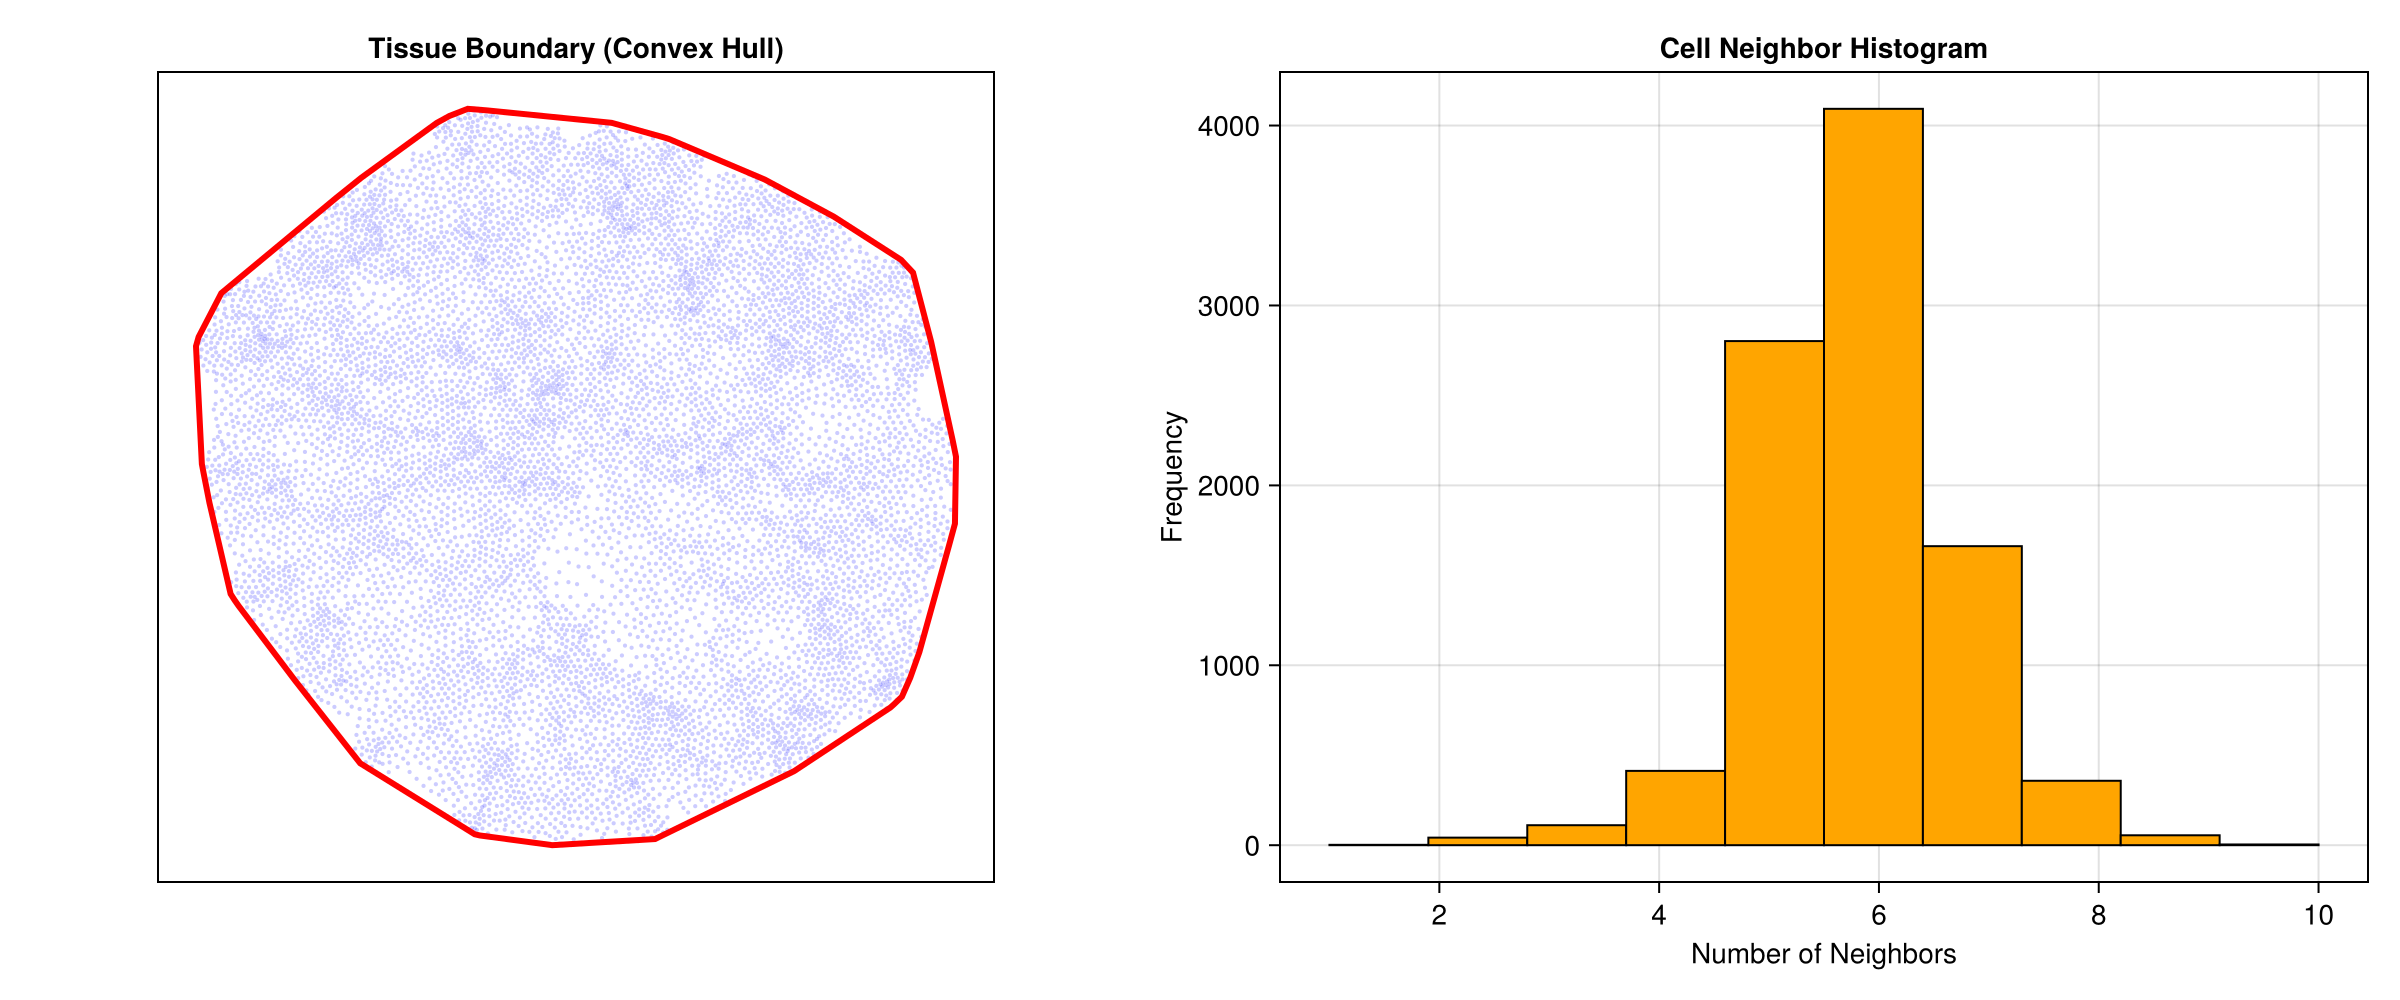

CairoMakie.Screen{IMAGE}


In [10]:
# ==========================================
# 6. Post-Processing: Shape Metrics & Neighbors
# ==========================================
using CairoMakie
using Statistics

println("Running Post-Processing Metrics...")

function get_centroids_and_neighbors(grid, N_cells)
    sums_x = zeros(Float64, N_cells)
    sums_y = zeros(Float64, N_cells)
    counts = zeros(Int, N_cells)
    
    # 2D Moore neighborhood offsets
    neighbors = [Set{Int}() for _ in 1:N_cells]
    w, h = size(grid)
    
    for x in 1:w, y in 1:h
        id = grid[x, y]
        if id > 0
            sums_x[id] += x
            sums_y[id] += y
            counts[id] += 1
            
            for dx in -1:1, dy in -1:1
                nx, ny = x + dx, y + dy
                if nx >= 1 && nx <= w && ny >= 1 && ny <= h
                    nid = grid[nx, ny]
                    if nid > 0 && nid != id
                        push!(neighbors[id], nid)
                    end
                end
            end
        end
    end
    
    centroids = Tuple{Float64, Float64}[]
    valid_neighbors = Int[]
    for i in 1:N_cells
        if counts[i] > 0
            push!(centroids, (sums_x[i]/counts[i], sums_y[i]/counts[i]))
            push!(valid_neighbors, length(neighbors[i]))
        end
    end
    return centroids, valid_neighbors
end

# A pure-Julia implementation of Graham Scan (Monotone Chain) for Convex Hull
function cross_product(o, a, b)
    return (a[1] - o[1]) * (b[2] - o[2]) - (a[2] - o[2]) * (b[1] - o[1])
end

function get_boundary_polygon(points)
    sort!(points)
    lower = empty(points)
    for p in points
        while length(lower) >= 2 && cross_product(lower[end-1], lower[end], p) <= 0
            pop!(lower)
        end
        push!(lower, p)
    end
    upper = empty(points)
    for p in reverse(points)
        while length(upper) >= 2 && cross_product(upper[end-1], upper[end], p) <= 0
            pop!(upper)
        end
        push!(upper, p)
    end
    pop!(lower)
    pop!(upper)
    return vcat(lower, upper)
end

function compute_shape_metrics(boundary)
    B = length(boundary)
    
    # 1. Centroid of the polygon
    cx = sum(p[1] for p in boundary) / B
    cy = sum(p[2] for p in boundary) / B
    
    # 2. Mean Radius (r)
    dists = [sqrt((p[1] - cx)^2 + (p[2] - cy)^2) for p in boundary]
    r = mean(dists)
    
    # 3. Boundary Width (w)
    w = std(dists, corrected=true)
    
    # 4. Boundary Length (C)
    C = 0.0
    for i in 1:B
        p1 = boundary[i]
        p2 = boundary[i == B ? 1 : i+1]
        C += sqrt((p1[1] - p2[1])^2 + (p1[2] - p2[2])^2)
    end
    
    # 5. Area (Shoelace Formula)
    A = 0.0
    for i in 1:B
        p1 = boundary[i]
        p2 = boundary[i == B ? 1 : i+1]
        A += p1[1] * p2[2] - p2[1] * p1[2]
    end
    A = abs(A) / 2.0
    
    # 6. Boundary Roughness (C / C_circle)
    C_circle = 2.0 * sqrt(pi * A)
    roughness = C / C_circle
    
    return r, w, roughness, boundary
end

# --- Execute ---
# Pull the final grid state from the GPU to the CPU
final_grid = Array(sol.u[end].grid)
N_final = Int(sol.u[end].N_cells[])

centroids, neighbor_counts = get_centroids_and_neighbors(final_grid, N_final)
boundary = get_boundary_polygon(centroids)
r, w, roughness, bound_pts = compute_shape_metrics(boundary)

println("\n
--- Final Monolayer Shape Metrics ---")
println("Mean Tissue Radius (r): ", round(r, digits=2))
println("Tissue Boundary Width (w): ", round(w, digits=2))
println("Tissue Boundary Roughness: ", round(roughness, digits=3))

# --- Plotting ---
fig = Figure(size=(1200, 500))

# 1. Plot the Centroids and the Boundary Polygon
ax1 = Axis(fig[1, 1], title="Tissue Boundary (Convex Hull)", aspect=DataAspect())
scatter!(ax1, [p[1] for p in centroids], [p[2] for p in centroids], color=(:blue, 0.2), markersize=3)

# To close the loop in lines!, append the first point to the end
b_x = [p[1] for p in bound_pts]
b_y = [p[2] for p in bound_pts]
push!(b_x, bound_pts[1][1])
push!(b_y, bound_pts[1][2])

lines!(ax1, b_x, b_y, color=:red, linewidth=3)
hidedecorations!(ax1)

# 2. Plot the Neighbor Histogram
ax2 = Axis(fig[1, 2], title="Cell Neighbor Histogram", xlabel="Number of Neighbors", ylabel="Frequency")
hist!(ax2, neighbor_counts, bins=maximum(neighbor_counts), color=:orange, strokewidth=1, strokecolor=:black)

display(fig)


